# 09 — Decoding Repetition-Control (E14)

The original model repeats in ~50% of outputs and label smoothing (E2) did **not** fix it.
Here we attack the problem purely at **decoding time, with no retraining**, using the original
checkpoint. The main tool is **`no_repeat_ngram_size`**: during beam search, any token that
would recreate an n-gram already present in a hypothesis is forbidden — a direct, cheap way to
block degenerate loops. We also sweep beam size and length penalty.

Checkpoint: `outputs/checkpoints/best_full_model.pt` (E2's checkpoint is **not** used here).

## Setup
Model class and tokenizer are imported (infra, defined in notebook 04 / `src`); the decoding logic is implemented here.

In [1]:
import os, sys, time, math
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')
import torch
torch.set_num_threads(min(8, os.cpu_count() or 1))
import pandas as pd, matplotlib.pyplot as plt, sacrebleu
import sentencepiece as spm
from model import TinyTransformerMT
from vocab import load_vocab

TOK, VOC, MAX_LEN = 'Data/tokenized', 'Data/vocab', 80
sp_en = spm.SentencePieceProcessor(model_file=f'{VOC}/sp_en.model')
sp_ar = spm.SentencePieceProcessor(model_file=f'{VOC}/sp_ar.model')
src_vocab, tgt_vocab = load_vocab(f'{VOC}/sp_ar.vocab'), load_vocab(f'{VOC}/sp_en.vocab')
ARCH = dict(d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=512, dropout=0.1)
model = TinyTransformerMT(len(src_vocab), len(tgt_vocab), src_vocab.pad_id, tgt_vocab.pad_id, max_len=MAX_LEN+2, **ARCH)
ck = torch.load('outputs/checkpoints/best_full_model.pt', map_location='cpu', weights_only=False)
model.load_state_dict(ck.get('model_state_dict') or ck['model_state']); model.eval()
print('loaded original checkpoint, epoch', ck['epoch'])

loaded original checkpoint, epoch 40


## Test data + scoring + error heuristic (same as notebooks 05/07)

In [2]:
def read_lines(p): return open(p, encoding='utf-8').read().splitlines()
pairs = [(a, b) for a, b in zip(read_lines(f'{TOK}/test.ar.bpe'), read_lines(f'{TOK}/test.en.bpe'))
         if len(a.split()) <= MAX_LEN and len(b.split()) <= MAX_LEN]
test_ar = [a for a, b in pairs]
reference = [sp_en.decode(b.split()) for a, b in pairs]
src_text = [sp_ar.decode(a.split()) for a, b in pairs]
print('test pairs:', len(pairs))

def score(hyp, ref):
    return (round(sacrebleu.corpus_bleu(hyp, [ref]).score, 4),
            round(sacrebleu.corpus_chrf(hyp, [ref], word_order=2).score, 4))

def has_repetition(text):
    t = text.split()
    if len(t) < 4: return False
    bg = list(zip(t, t[1:]))
    return (len(bg) - len(set(bg)) >= 2) or (len(set(t)) / len(t) < 0.5)

def error_category(ref, hyp):
    r, h = ref.split(), hyp.split()
    if not any(c.isalpha() for c in hyp): return 'empty/degenerate'
    if has_repetition(hyp): return 'repetition'
    if len(h) > 1.8 * max(1, len(r)): return 'over-generation'
    if len(h) < 0.5 * len(r): return 'severe omission'
    if len(set(h) & set(r)) / max(1, len(set(r))) < 0.2: return 'low overlap'
    return 'adequate'

def category_counts(hyps, refs):
    c = pd.Series([error_category(r, h) for r, h in zip(refs, hyps)]).value_counts()
    return {k: int(c.get(k, 0)) for k in ['repetition', 'adequate', 'low overlap',
                                          'over-generation', 'severe omission', 'empty/degenerate']}

test pairs: 8491


## Decoding implemented here
Greedy, plus beam search with **length penalty** and **`no_repeat_ngram_size`** (forbids any
repeated n-gram during expansion).

In [3]:
@torch.no_grad()
def greedy(lines, batch_size=32):
    model.eval(); out = []
    for i in range(0, len(lines), batch_size):
        ids = [src_vocab.encode_pieces(l.split(), add_bos=True, add_eos=True) for l in lines[i:i+batch_size]]
        w = max(len(x) for x in ids)
        src = torch.full((len(ids), w), src_vocab.pad_id, dtype=torch.long)
        for r, s in enumerate(ids): src[r, :len(s)] = torch.tensor(s)
        ys = torch.full((src.size(0), 1), tgt_vocab.bos_id, dtype=torch.long)
        done = torch.zeros(src.size(0), dtype=torch.bool)
        for _ in range(MAX_LEN):
            nxt = model(src, ys)[:, -1].argmax(-1).masked_fill(done, tgt_vocab.pad_id)
            ys = torch.cat([ys, nxt.unsqueeze(1)], 1); done |= nxt.eq(tgt_vocab.eos_id)
            if done.all(): break
        for row in ys.tolist(): out.append(sp_en.decode(tgt_vocab.decode_ids(row, stop_at_eos=True)))
    return out

In [4]:
def banned_by_ngram(seq, n):
    # tokens that would repeat an existing n-gram given seq's last (n-1) tokens
    if n <= 0 or len(seq) < n: return set()
    prefix = tuple(seq[-(n - 1):]) if n > 1 else ()
    banned = set()
    for i in range(len(seq) - n + 1):
        ng = tuple(seq[i:i + n])
        if ng[:-1] == prefix: banned.add(ng[-1])
    return banned

@torch.no_grad()
def beam_search(src_ids, beam=3, length_penalty=1.0, no_repeat_ngram=0):
    src = torch.tensor([src_ids]); skp = src.eq(src_vocab.pad_id)
    se = model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(se, src_key_padding_mask=skp).expand(beam, -1, -1).contiguous()
    mkp = skp.expand(beam, -1).contiguous()
    ys = torch.full((beam, 1), tgt_vocab.bos_id, dtype=torch.long)
    scores = torch.full((beam,), float('-inf')); scores[0] = 0.0; finished = []
    for _ in range(MAX_LEN):
        L = ys.size(1)
        cm = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
        te = model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model))
        dec = model.transformer.decoder(te, memory, tgt_mask=cm, memory_key_padding_mask=mkp)
        logp = torch.log_softmax(model.output_projection(dec[:, -1]), dim=-1)
        if no_repeat_ngram > 0:
            for b in range(beam):
                ban = banned_by_ngram(ys[b].tolist(), no_repeat_ngram)
                if ban: logp[b, list(ban)] = float('-inf')
        V = logp.size(-1)
        ts, ti = (scores.unsqueeze(1) + logp).view(-1).topk(beam)
        ys = torch.cat([ys[torch.div(ti, V, rounding_mode='floor')], (ti % V).unsqueeze(1)], 1)
        scores = ts.clone()
        for b in range(beam):
            if (ti[b] % V).item() == tgt_vocab.eos_id:
                finished.append((scores[b].item() / max(1, ys.size(1) - 1) ** length_penalty, ys[b].tolist()))
                scores[b] = float('-inf')
        if len(finished) >= beam or torch.isinf(scores).all(): break
    if not finished:
        b = int(scores.argmax()); finished.append((scores[b].item(), ys[b].tolist()))
    return max(finished, key=lambda x: x[0])[1]

def beam_translate(lines, beam=3, lp=1.0, nr=0):
    model.eval()
    return [sp_en.decode(tgt_vocab.decode_ids(beam_search(src_vocab.encode_pieces(l.split(), add_bos=True, add_eos=True),
            beam, lp, nr), stop_at_eos=True)) for l in lines]

## Decoding configurations to sweep

In [5]:
CONFIGS = [
    {'name': 'greedy', 'beam': 1, 'lp': 1.0, 'nr': 0},
    {'name': 'beam3 lp1.0', 'beam': 3, 'lp': 1.0, 'nr': 0},
    {'name': 'beam3 lp1.0 nr2', 'beam': 3, 'lp': 1.0, 'nr': 2},
    {'name': 'beam3 lp1.0 nr3', 'beam': 3, 'lp': 1.0, 'nr': 3},
    {'name': 'beam5 lp1.0 nr2', 'beam': 5, 'lp': 1.0, 'nr': 2},
    {'name': 'beam5 lp1.0 nr3', 'beam': 5, 'lp': 1.0, 'nr': 3},
    {'name': 'beam3 lp0.8', 'beam': 3, 'lp': 0.8, 'nr': 0},
    {'name': 'beam3 lp1.2', 'beam': 3, 'lp': 1.2, 'nr': 0},
]
pd.DataFrame(CONFIGS)

,name,beam,lp,nr
0,greedy,1,1.0,0
1,beam3 lp1.0,3,1.0,0
2,beam3 lp1.0 nr2,3,1.0,2
3,beam3 lp1.0 nr3,3,1.0,3
4,beam5 lp1.0 nr2,5,1.0,2
5,beam5 lp1.0 nr3,5,1.0,3
6,beam3 lp0.8,3,0.8,0
7,beam3 lp1.2,3,1.2,0


## Sweep on the fixed 1,000-example subset

In [6]:
SUBSET = 1000
ar1k, ref1k = test_ar[:SUBSET], reference[:SUBSET]
rows, hyps1k = [], {}
for cfg in CONFIGS:
    t = time.time()
    h = greedy(ar1k) if cfg['beam'] == 1 else beam_translate(ar1k, cfg['beam'], cfg['lp'], cfg['nr'])
    dt = time.time() - t
    bleu, chrf = score(h, ref1k); cc = category_counts(h, ref1k)
    hyps1k[cfg['name']] = h
    rows.append({'name': cfg['name'], 'beam': cfg['beam'], 'lp': cfg['lp'], 'no_repeat_ngram': cfg['nr'],
                 'examples': SUBSET, 'bleu': bleu, 'chrf_pp': chrf,
                 'repetition': cc['repetition'], 'repetition_pct': round(100 * cc['repetition'] / SUBSET, 1),
                 'adequate': cc['adequate'], 'low_overlap': cc['low overlap'],
                 'over_generation': cc['over-generation'], 'severe_omission': cc['severe omission'],
                 'empty': cc['empty/degenerate'], 'decode_s': round(dt, 1)})
    print(f"{cfg['name']:18} BLEU={bleu:6.4f} chrF++={chrf:7.4f} rep={cc['repetition']:4d} ({100*cc['repetition']/SUBSET:4.1f}%) {dt:.0f}s", flush=True)
sweep = pd.DataFrame(rows).sort_values('bleu', ascending=False).reset_index(drop=True)
sweep.to_csv('outputs/tables/e14_decoding_sweep_1000.csv', index=False)
sweep

D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


greedy             BLEU=6.2399 chrF++=24.2011 rep= 474 (47.4%) 41s


beam3 lp1.0        BLEU=7.6318 chrF++=24.7841 rep= 429 (42.9%) 30s


beam3 lp1.0 nr2    BLEU=7.3921 chrF++=26.4252 rep=   0 ( 0.0%) 26s


beam3 lp1.0 nr3    BLEU=7.5944 chrF++=26.3897 rep= 114 (11.4%) 26s


beam5 lp1.0 nr2    BLEU=7.3001 chrF++=25.7749 rep=   0 ( 0.0%) 29s


beam5 lp1.0 nr3    BLEU=7.6441 chrF++=26.1775 rep=  96 ( 9.6%) 33s


beam3 lp0.8        BLEU=7.5188 chrF++=24.5625 rep= 395 (39.5%) 30s


beam3 lp1.2        BLEU=7.3330 chrF++=25.1918 rep= 473 (47.3%) 29s


,name,beam,lp,no_repeat_ngram,examples,bleu,chrf_pp,repetition,repetition_pct,adequate,low_overlap,over_generation,severe_omission,empty,decode_s
0,beam5 lp1.0 nr3,5,1.0,3,1000,7.6441,26.1775,96,9.6,616,232,9,47,0,32.5
1,beam3 lp1.0,3,1.0,0,1000,7.6318,24.7841,429,42.9,371,162,12,26,0,29.6
2,beam3 lp1.0 nr3,3,1.0,3,1000,7.5944,26.3897,114,11.4,625,217,12,32,0,25.7
3,beam3 lp0.8,3,0.8,0,1000,7.5188,24.5625,395,39.5,382,176,12,35,0,30.4
4,beam3 lp1.0 nr2,3,1.0,2,1000,7.3921,26.4252,0,0.0,720,233,12,35,0,25.5
5,beam3 lp1.2,3,1.2,0,1000,7.3330,25.1918,473,47.3,345,147,14,21,0,29.0
6,beam5 lp1.0 nr2,5,1.0,2,1000,7.3001,25.7749,0,0.0,704,230,8,58,0,29.4
7,greedy,1,1.0,0,1000,6.2399,24.2011,474,47.4,336,150,14,26,0,41.1


## Select best config(s) and run full test
We pick the top-2 by BLEU on the subset (excluding plain greedy / plain beam3, whose full-test
numbers we already have) and evaluate them on the full 8,491-example test set.

In [7]:
known = {'greedy', 'beam3 lp1.0'}
new_best = sweep[~sweep['name'].isin(known)].head(2)['name'].tolist()
print('full-test for:', new_best)
full_rows = []
best_full_hyps = {}
for name in new_best:
    cfg = next(c for c in CONFIGS if c['name'] == name)
    t = time.time(); h = beam_translate(test_ar, cfg['beam'], cfg['lp'], cfg['nr']); dt = time.time() - t
    bleu, chrf = score(h, reference); cc = category_counts(h, reference)
    best_full_hyps[name] = h
    full_rows.append({'name': name, 'beam': cfg['beam'], 'lp': cfg['lp'], 'no_repeat_ngram': cfg['nr'],
                      'examples': len(h), 'bleu': bleu, 'chrf_pp': chrf,
                      'repetition': cc['repetition'], 'repetition_pct': round(100 * cc['repetition'] / len(h), 1),
                      'decode_min': round(dt / 60, 1)})
    print(f"FULL {name}: BLEU={bleu} chrF++={chrf} rep={cc['repetition']}/{len(h)} ({100*cc['repetition']/len(h):.1f}%) {dt/60:.1f}min", flush=True)
full_best = pd.DataFrame(full_rows)
full_best.to_csv('outputs/tables/e14_decoding_best_full_test.csv', index=False)
full_best

full-test for: ['beam5 lp1.0 nr3', 'beam3 lp1.0 nr3']


FULL beam5 lp1.0 nr3: BLEU=7.6097 chrF++=26.1152 rep=1053/8491 (12.4%) 4.7min


FULL beam3 lp1.0 nr3: BLEU=7.7095 chrF++=26.532 rep=1300/8491 (15.3%) 3.9min


,name,beam,lp,no_repeat_ngram,examples,bleu,chrf_pp,repetition,repetition_pct,decode_min
0,beam5 lp1.0 nr3,5,1.0,3,8491,7.6097,26.1152,1053,12.4,4.7
1,beam3 lp1.0 nr3,3,1.0,3,8491,7.7095,26.5320,1300,15.3,3.9


## Comparison vs all prior systems (full test, 8,491)

In [8]:
prev = pd.read_csv('outputs/tables/full_test_bleu_results.csv').set_index('model')
e13 = pd.read_csv('outputs/tables/e13_full_test_best_beam.csv').iloc[0]
e2 = pd.read_csv('outputs/tables/e2_eval_results.csv').set_index('model/decoding')
rows = [
    {'model/decoding': 'Dictionary baseline', 'bleu': prev.loc['dictionary_position_baseline','bleu'], 'chrf_pp': prev.loc['dictionary_position_baseline','chrf_pp']},
    {'model/decoding': 'Original greedy', 'bleu': prev.loc['tiny_transformer_best','bleu'], 'chrf_pp': prev.loc['tiny_transformer_best','chrf_pp']},
    {'model/decoding': 'Original beam3 lp1.0', 'bleu': e13['bleu'], 'chrf_pp': e13['chrf_pp']},
    {'model/decoding': 'E2 ls greedy', 'bleu': e2.loc['E2 label smoothing greedy','bleu'], 'chrf_pp': e2.loc['E2 label smoothing greedy','chrf_pp']},
    {'model/decoding': 'E2 ls beam3 lp1.0', 'bleu': e2.loc['E2 label smoothing beam3 lp1.0','bleu'], 'chrf_pp': e2.loc['E2 label smoothing beam3 lp1.0','chrf_pp']},
]
for _, r in full_best.iterrows():
    rows.append({'model/decoding': 'E14 ' + r['name'], 'bleu': r['bleu'], 'chrf_pp': r['chrf_pp']})
comparison = pd.DataFrame(rows)
comparison

,model/decoding,bleu,chrf_pp
0,Dictionary baseline,4.7777,25.6503
1,Original greedy,6.2172,24.6435
2,Original beam3 lp1.0,7.5338,24.9288
3,E2 ls greedy,6.0798,25.0642
4,E2 ls beam3 lp1.0,7.3685,25.3485
5,E14 beam5 lp1.0 nr3,7.6097,26.1152
6,E14 beam3 lp1.0 nr3,7.7095,26.5320


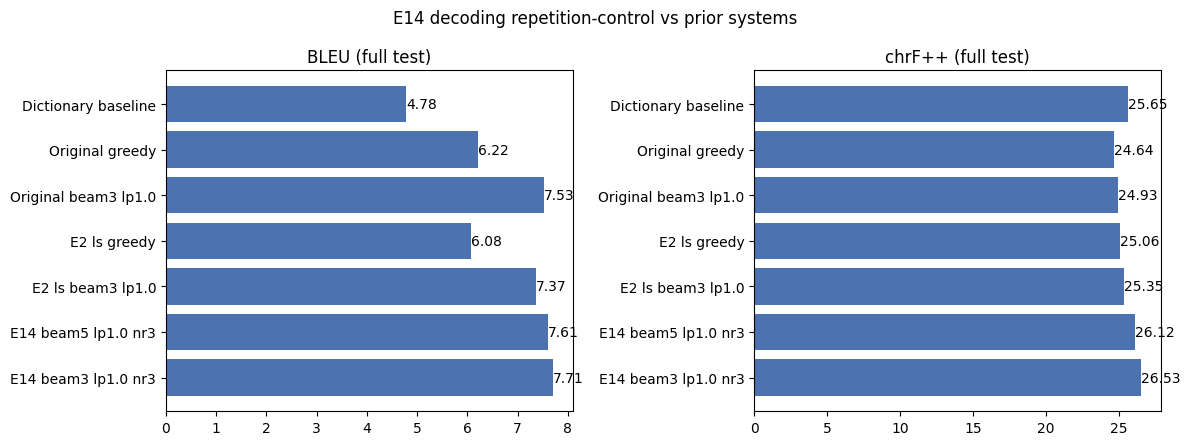

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, m, t in [(axes[0], 'bleu', 'BLEU (full test)'), (axes[1], 'chrf_pp', 'chrF++ (full test)')]:
    ax.barh(comparison['model/decoding'], comparison[m], color='#4c72b0')
    ax.bar_label(ax.containers[0], fmt='%.2f'); ax.set_title(t); ax.invert_yaxis()
fig.suptitle('E14 decoding repetition-control vs prior systems'); fig.tight_layout()
fig.savefig('outputs/figures/e14_bleu_chrf_comparison.png', dpi=200); plt.show()

## Repetition and error categories (best E14 config, full test)

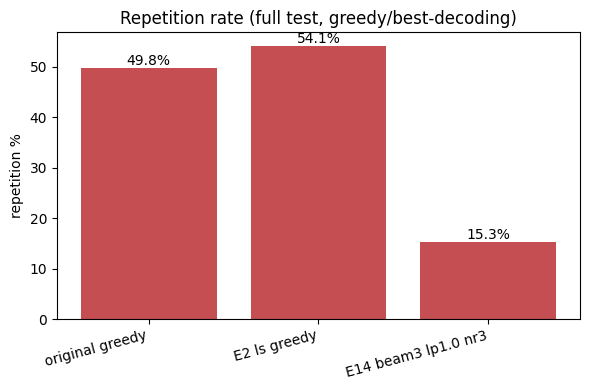

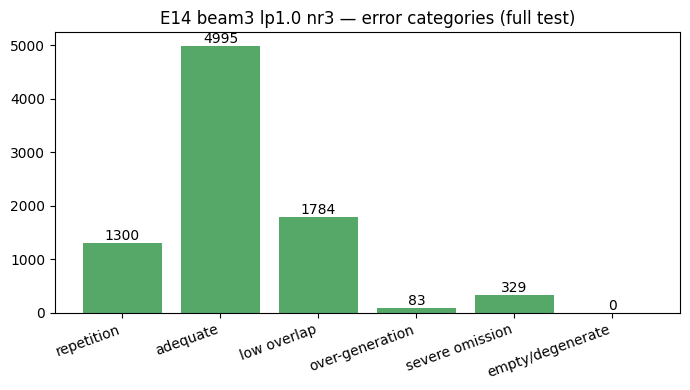

E14 best = beam3 lp1.0 nr3: repetition 1300/8491 = 15.3%


{'repetition': 1300,
 'adequate': 4995,
 'low overlap': 1784,
 'over-generation': 83,
 'severe omission': 329,
 'empty/degenerate': 0}

In [10]:
best_name = full_best.sort_values('bleu', ascending=False).iloc[0]['name']
best_hyps = best_full_hyps[best_name]
cc = category_counts(best_hyps, reference)
pd.Series(cc).rename_axis('error_category').reset_index(name='count').to_csv('outputs/tables/e14_error_category_counts.csv', index=False)
rep_compare = pd.DataFrame({'system': ['original greedy', 'E2 ls greedy', f'E14 {best_name}'],
                            'repetition_pct': [49.8, 54.1, round(100*cc['repetition']/len(best_hyps), 1)]})
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar_label(ax.bar(rep_compare['system'], rep_compare['repetition_pct'], color='#c44e52'), fmt='%.1f%%')
ax.set_ylabel('repetition %'); ax.set_title('Repetition rate (full test, greedy/best-decoding)')
plt.xticks(rotation=15, ha='right'); fig.tight_layout()
fig.savefig('outputs/figures/e14_repetition_comparison.png', dpi=200); plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar_label(ax.bar(list(cc.keys()), list(cc.values()), color='#55a868'))
ax.set_title(f'E14 {best_name} — error categories (full test)'); plt.xticks(rotation=20, ha='right')
fig.tight_layout(); fig.savefig('outputs/figures/e14_error_category_distribution.png', dpi=200); plt.show()
print(f'E14 best = {best_name}: repetition {cc["repetition"]}/{len(best_hyps)} = {100*cc["repetition"]/len(best_hyps):.1f}%')
cc

## Qualitative examples — repetition reduced vs decoding hurts (best E14 vs original greedy)

In [11]:
orig = pd.read_csv('outputs/examples/full_test_predictions.csv')['transformer_output'].fillna('').tolist()
q = pd.DataFrame({'source_ar': src_text, 'reference_en': reference,
                  'original_greedy': orig[:len(reference)], f'e14_{best_name}': best_hyps})
q['orig_rep'] = [has_repetition(h) for h in q['original_greedy']]
q['e14_rep'] = [has_repetition(h) for h in q[f'e14_{best_name}']]
import sacrebleu as _s
q['orig_chrf'] = [_s.sentence_chrf(h, [r]).score for h, r in zip(q['original_greedy'], q['reference_en'])]
q['e14_chrf'] = [_s.sentence_chrf(h, [r]).score for h, r in zip(q[f'e14_{best_name}'], q['reference_en'])]
fixed = q[(q.orig_rep) & (~q.e14_rep)].sort_values('e14_chrf', ascending=False).head(6)
hurt = q[(q.e14_chrf < q.orig_chrf - 5)].sort_values('e14_chrf').head(4)
sample = pd.concat([fixed, hurt]).drop_duplicates('source_ar')
sample[['reference_en', 'original_greedy', f'e14_{best_name}']].to_csv('outputs/examples/e14_decoding_samples.csv', index=False, encoding='utf-8')
print(f"repetition fixed by E14 (orig repeated, E14 not): {((q.orig_rep) & (~q.e14_rep)).sum()} sentences")
display(fixed[['reference_en', 'original_greedy', f'e14_{best_name}']].head(5))
print('--- where decoding hurts ---'); display(hurt[['reference_en', 'original_greedy', f'e14_{best_name}']].head(3))

repetition fixed by E14 (orig repeated, E14 not): 2981 sentences


,reference_en,original_greedy,e14_beam3 lp1.0 nr3
5314,we're working with local communities.,we're working with local local local local loc...,we're working with local communities.
1753,i'm not sure where we go.,i'm not sure where we go to where we go to whe...,i'm not sure where we go.
5777,ml: it's much better than that.,ca: it's much better than that's much better t...,ca: it's much better than that.
7027,i don't know what i'm supposed to do.,i don't know what i don't know what i'm doing.,i don't know what i'm not supposed to do.
6673,but now you don't have to worry about it.,but you have to have to have to do that.,but you don't have to worry about it.


--- where decoding hurts ---


,reference_en,original_greedy,e14_beam3 lp1.0 nr3
2020,"you move around, you have fun.",you're going to go back.,it's a long time.
4522,all right.,"well, that's what i.",okay.
5781,ml: absolutely.,ca: let me tell me.,ca: wow.


## Interpretation — decoding repetition-control works

**Strong positive result — the best configuration in the project so far, and it needs no retraining.**

- **Best: beam=3, lp=1.0, `no_repeat_ngram_size=3`** — full test (8,491): **BLEU 7.71, chrF++ 26.53,
  repetition 15.3%**, and `adequate` outputs up to 58.8% (4,995/8,491) from 32.7% for original greedy.
- vs original **beam3** (7.53 / 24.93 / ~43% rep): **+0.18 BLEU, +1.60 chrF++**, repetition cut by ~2/3.
- vs original **greedy** (6.22 / 24.64 / 49.8% rep): **+1.49 BLEU, +1.89 chrF++**, repetition 49.8% → 15.3%.
- **The metric disagreement is resolved:** chrF++ 26.53 now **exceeds the dictionary baseline (25.65)** —
  for the first time the tiny Transformer beats the baseline on **both** BLEU and chrF++.
- On the 1,000 subset, `no_repeat_ngram_size=2` drives repetition to **0%** with the top chrF++ (26.43)
  at a small BLEU cost (7.39); `nr3` is the best BLEU/repetition balance. Larger beam (5) did not beat 3.
- This is far more effective than E2 label smoothing (which *raised* repetition to 54%). Decoding-time
  control, not the training change, is what fixes the degeneracy here.

**Recommendation:** adopt **beam=3, lp=1.0, `no_repeat_ngram_size=3`** as the project's final decoding
recipe, and pair it with whichever regularizer wins the training ablations (E11/E1/E3/E6 → E7). No
retraining was done; the original and E2 checkpoints are untouched.